# (샘플) CNN hynn, iu

In [1]:
import tensorflow as tf

In [2]:
import tensorflow.experimental.numpy as tnp

In [3]:
tnp.experimental_enable_numpy_behavior()

In [4]:
import numpy as np

In [5]:
import requests
import re
import json
from PIL import Image

In [6]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return list(set(urls))     # dedupe
            if 'next' not in data: return list(set(urls))
            requestUrl = url + data['next']
        except:
            pass

### 이미지 크롤링의 개요 

`-` "검색 -> 이미지주소 -> 저장" 을 반복하면 된다. 

### get url: 검색 -> 이미지주소

In [7]:
iu_lst = search_images_ddg('iu',max_n=50)

In [9]:
iu_lst[0]

'https://1409791524.rsc.cdn77.org/data/images/full/571521/iu-celebrity-unquestionably-all-kill-on-the-charts-reaching-no-1-melon-24hits-in-3-hours.jpg'

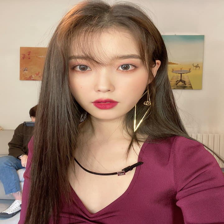

In [11]:
img=Image.open(Image.io.BytesIO(requests.get(iu_lst[0]).content))
img=img.resize((224,224))
img

In [12]:
X = tf.constant(img,dtype=tf.float64).reshape(1,224,224,3)

2022-05-16 13:11:44.093218: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [13]:
X

<tf.Tensor: shape=(1, 224, 224, 3), dtype=float64, numpy=
array([[[[207., 192., 173.],
         [207., 192., 173.],
         [207., 192., 173.],
         ...,
         [211., 198., 182.],
         [211., 198., 182.],
         [211., 198., 182.]],

        [[208., 193., 174.],
         [208., 193., 174.],
         [209., 194., 175.],
         ...,
         [213., 200., 184.],
         [214., 201., 185.],
         [214., 201., 185.]],

        [[210., 195., 176.],
         [210., 195., 176.],
         [211., 196., 177.],
         ...,
         [215., 202., 186.],
         [216., 203., 187.],
         [216., 203., 187.]],

        ...,

        [[200., 197., 191.],
         [202., 199., 194.],
         [204., 200., 197.],
         ...,
         [120.,  41.,  68.],
         [123.,  40.,  69.],
         [123.,  41.,  69.]],

        [[206., 202., 199.],
         [207., 203., 201.],
         [209., 205., 204.],
         ...,
         [ 93.,  19.,  43.],
         [ 92.,  16.,  41.],
         

### 이미지주소 -> 저장 

In [14]:
import tqdm

In [ ]:
for url in tqdm.tqdm(iu_lst[1:]): 
    try: 
        img=Image.open(Image.io.BytesIO(requests.get(url).content))
        img=img.resize((224,224))
        X= tf.concat([X,tf.constant(img,dtype=tf.float64).reshape(1,224,224,3)],axis=0)
    except: 
        print(url)

 47%|████▋     | 23/49 [00:42<02:03,  4.74s/it]

http://www.kpopmusic.com/wp-content/uploads/2015/10/iU-Wallpaper_21.jpg


 49%|████▉     | 24/49 [00:52<02:40,  6.40s/it]

http://4.bp.blogspot.com/-378t4zKUpu0/TqdVp8TLruI/AAAAAAAAAU4/T3Eu8_qVTOk/s1600/IU_singer_7.jpg


 51%|█████     | 25/49 [01:03<03:06,  7.79s/it]

...

https://image.kpopmap.com/2020/11/iu-blueming-2.jpg


 57%|█████▋    | 28/49 [01:38<03:43, 10.62s/it]

https://datacdn.btimesonline.com/data/images/full/101337/iu.jpg


 59%|█████▉    | 29/49 [01:50<03:36, 10.81s/it]

https://lastfm.freetls.fastly.net/i/u/ar0/2550960d7ed0419310ca46d758ad08c6.jpg
